In [11]:
from datetime import datetime

import polars as pl
from epicsarchiver import ArchiverAppliance
%matplotlib inline

In [12]:
archiver = ArchiverAppliance("archiver-01.tn.esss.lu.se")

In [13]:
pv = "CrS-ACCP:CRYO-AI-21570:Val"

In [14]:
archiver.get_pv_status(pv)
# NBVAL_IGNORE_OUTPUT

[{'appliance': 'archiver-02',
  'pvName': 'CrS-ACCP:CRYO-AI-21570:Val',
  'pvNameOnly': 'CrS-ACCP:CRYO-AI-21570:Val',
  'status': 'Paused'}]

In [15]:
df = archiver.get_data(pv, "20181121 07:00", datetime(2018, 11, 21, 8))

In [16]:
df.head()

date,val,severity,status,field_values,headers
"datetime[ns, UTC]",f64,i32,i32,list[struct[2]],list[struct[2]]
2018-11-21 06:59:55.092628183 UTC,-43.243271,0,0,[],"[{""EGU"",""vpm""}, {""PREC"",""2""}]"
2018-11-21 07:00:03.231749333 UTC,-43.243271,0,0,[],"[{""EGU"",""vpm""}, {""PREC"",""2""}]"
2018-11-21 07:00:03.448221408 UTC,-43.083405,0,0,[],"[{""EGU"",""vpm""}, {""PREC"",""2""}]"
2018-11-21 07:00:03.645798060 UTC,-43.218681,0,0,[],"[{""EGU"",""vpm""}, {""PREC"",""2""}]"
2018-11-21 07:00:03.868238879 UTC,-43.335503,0,0,[],"[{""EGU"",""vpm""}, {""PREC"",""2""}]"


In [17]:
df.describe()

statistic,date,val,severity,status,field_values,headers
str,str,f64,f64,f64,f64,f64
"""count""","""3961""",3961.0,3961.0,3961.0,3961.0,3961.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""","""2018-11-21 07:29:58.471211+00:…",-43.179499,0.0,0.0,null,null
"""std""",null,0.141828,0.0,0.0,null,null
"""min""","""2018-11-21 06:59:55.092628+00:…",-43.440033,0.0,0.0,null,null
"""25%""","""2018-11-21 07:14:54.763173+00:…",-43.323212,0.0,0.0,null,null
"""50%""","""2018-11-21 07:29:55.272556+00:…",-43.157196,0.0,0.0,null,null
"""75%""","""2018-11-21 07:44:54.895322+00:…",-43.040367,0.0,0.0,null,null
"""max""","""2018-11-21 07:59:55.181673+00:…",-42.954285,0.0,0.0,null,null


In [18]:
from pytz import UTC

df1 = df.filter(pl.col("date") < datetime(2018, 11, 21, 7, 1, tzinfo=UTC))

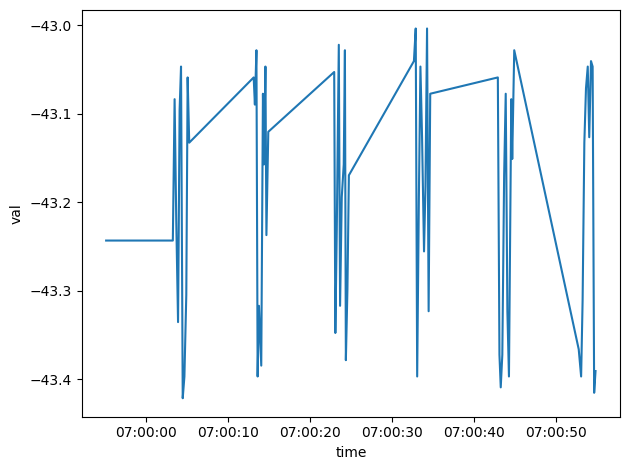

In [19]:
import matplotlib.pyplot as plt

plt.plot(df1["date"], df1["val"])
plt.xlabel("time")
plt.ylabel("val")
plt.tight_layout()
# NBVAL_IGNORE_OUTPUT